## Exploratory Data Analysis

This notebook analyzes the supplied e-commerce dynamic-pricing dataset before model development.

**Project focus:** pricing, discounts, customer behavior, purchase probability, product categories and time-based patterns.

## Load Dataset

In [2]:

# PricePilot AI - Exploratory Data Analysis
# Dynamic Pricing Optimization & Revenue Intelligence System

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/ecommerce_dynamic_pricing_dataset.csv"
OUTPUT_DIR = "../eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 2044 rows × 13 columns


,Transaction_ID,Product_ID,Product_Category,Price,Discount,Customer_ID,Customer_Age,Customer_Gender,Purchase_Timestamp,Payment_Method,Shipping_Type,Review_Rating,Purchase Probability
0,T180787,P8392,Books,15.58,0.46,C66501,49,Male,3/31/2024 14:16,Credit Card,Express,1,0
1,T750990,P5778,Books,62.00,12.27,C12853,26,Other,2/10/2024 9:31,Debit Card,Express,2,1
2,T627626,P5136,Home & Kitchen,958.29,61.67,C74523,23,Male,5/23/2024 13:04,Debit Card,Express,4,0
3,T602068,P5945,Electronics,657.01,135.43,C31822,33,Female,6/22/2024 9:20,PayPal,Standard,1,0
4,T286338,P8427,Home & Kitchen,147.16,22.23,C84859,40,Other,5/16/2024 6:15,Credit Card,Express,2,1


## 1. Dataset Overview

In [3]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nStatistical summary:")
display(df.describe(include="all").T)


Shape: (2044, 13)

Columns:
['Transaction_ID', 'Product_ID', 'Product_Category', 'Price', 'Discount', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'Purchase_Timestamp', 'Payment_Method', 'Shipping_Type', 'Review_Rating', 'Purchase Probability']

Data types:


,dtype
Transaction_ID,str
Product_ID,str
Product_Category,str
Price,float64
Discount,float64
Customer_ID,str
Customer_Age,int64
Customer_Gender,str
Purchase_Timestamp,str
Payment_Method,str



Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,2044,1244,T741866,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,2044,1157,P1036,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,2044,4,Clothing,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2044.0,NaN,NaN,NaN,502.781605,285.287579,10.86,253.05,492.12,752.43,998.64
Discount,2044.0,NaN,NaN,NaN,76.70703,68.683003,0.09,21.04,54.04,114.575,292.63
Customer_ID,2044,1236,C31497,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,2044.0,NaN,NaN,NaN,44.120841,15.035008,18.0,31.0,45.0,56.0,70.0
Customer_Gender,2044,3,Male,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Timestamp,2044,1243,6/30/2024 0:10,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,2044,4,Credit Card,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Values & Duplicates

In [4]:

missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean()*100).round(2)
})
display(missing)

duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

print("\nImportant observation:")
print("Exact duplicates are retained in the raw dataset for EDA transparency.")
print("For modeling, duplicates should be investigated before deciding whether to remove them.")


,Missing Values,Missing %
Transaction_ID,0,0.0
Product_ID,0,0.0
Product_Category,0,0.0
Price,0,0.0
Discount,0,0.0
Customer_ID,0,0.0
Customer_Age,0,0.0
Customer_Gender,0,0.0
Purchase_Timestamp,0,0.0
Payment_Method,0,0.0


Exact duplicate rows: 799 (39.09%)

Important observation:
Exact duplicates are retained in the raw dataset for EDA transparency.
For modeling, duplicates should be investigated before deciding whether to remove them.


## 3. Unique Values & Categorical Analysis


Transaction_ID: 1244 unique values


,count
Transaction_ID,
T741866,8
T841728,7
T417121,6
T530590,6
T592415,6
T935818,5
T288218,5
T865416,5
T883047,5



Product_ID: 1157 unique values


,count
Product_ID,
P1036,10
P6914,9
P4699,8
P6673,6
P6271,6
P2945,6
P4357,6
P1536,6
P6546,6



Product_Category: 4 unique values


...

,count
Purchase_Timestamp,
6/30/2024 0:10,8
8/3/2024 4:19,7
7/29/2024 9:22,6
8/6/2024 0:23,6
4/30/2024 23:22,6
12/29/2024 23:09,5
4/17/2024 17:35,5
11/30/2024 15:37,5
12/9/2024 14:47,5



Payment_Method: 4 unique values


,count
Payment_Method,
Credit Card,559
Debit Card,526
Net Banking,481
PayPal,478



Shipping_Type: 2 unique values


,count
Shipping_Type,
Standard,1029
Express,1015


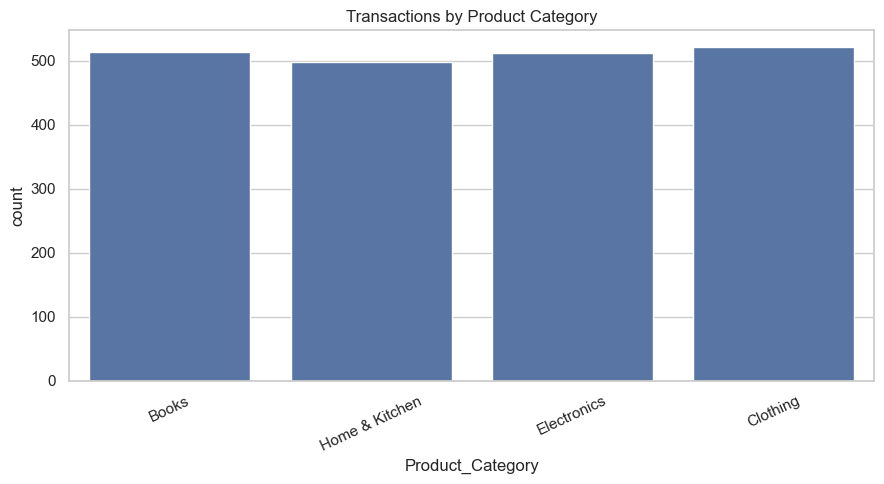

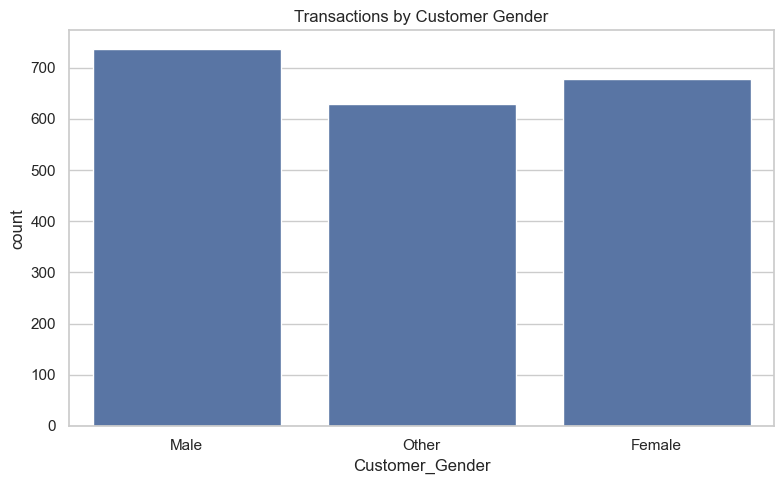

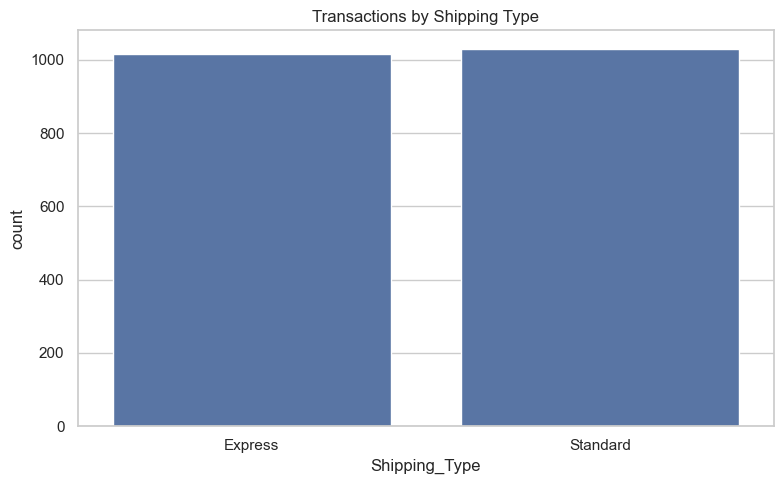

In [5]:

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}: {df[col].nunique()} unique values")
    display(df[col].value_counts().head(10).to_frame("count"))

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Product_Category")
plt.title("Transactions by Product Category")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/transactions_by_category.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Customer_Gender")
plt.title("Transactions by Customer Gender")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/transactions_by_gender.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Shipping_Type")
plt.title("Transactions by Shipping Type")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shipping_type.png", dpi=200)
plt.show()


## 4. Numerical Distributions

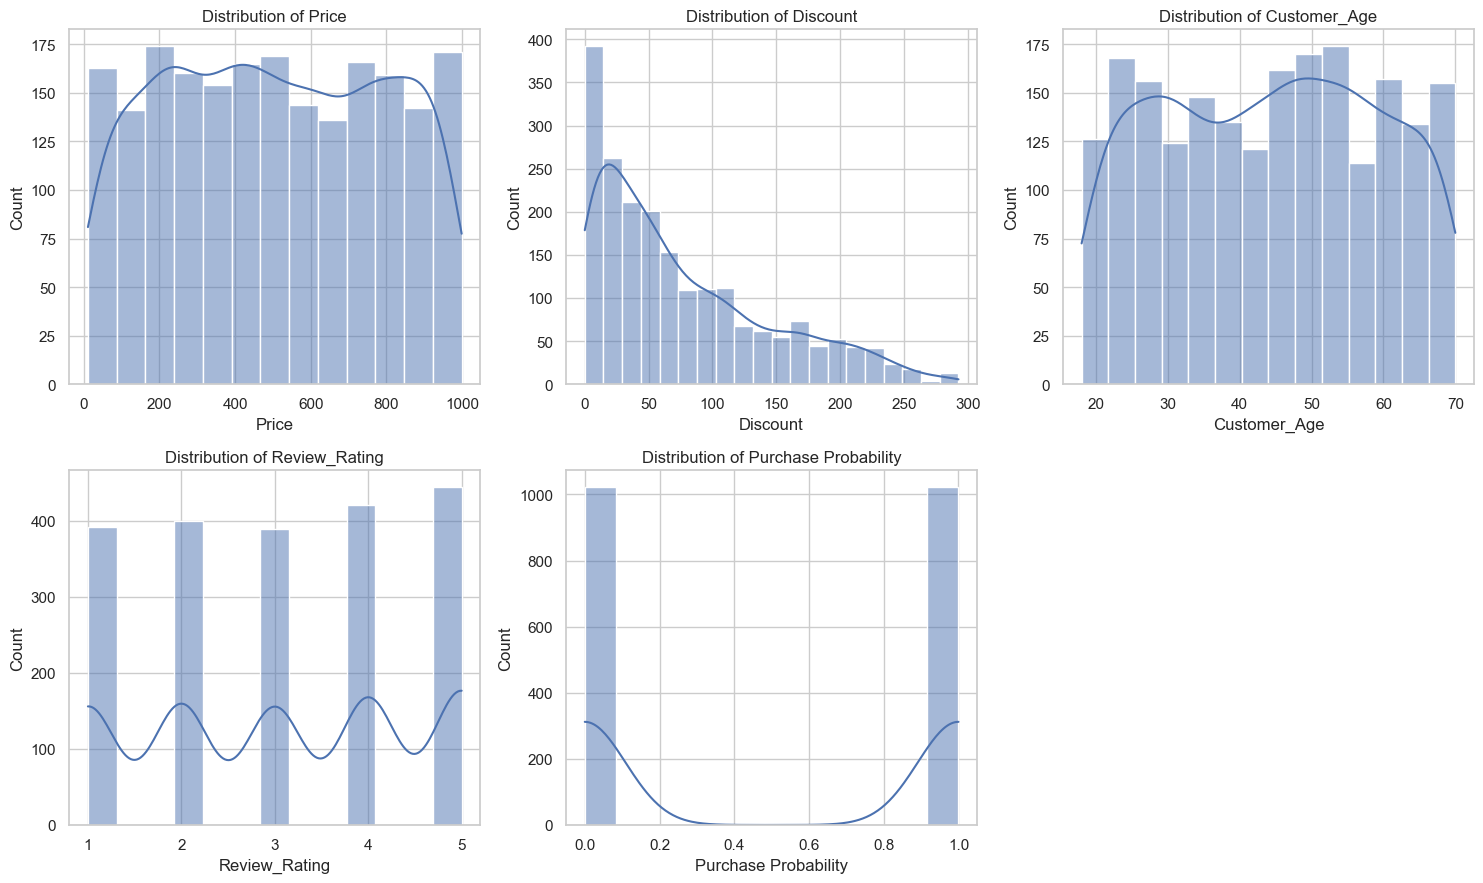

In [6]:

numeric_cols = ["Price", "Discount", "Customer_Age", "Review_Rating", "Purchase Probability"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/numeric_distributions.png", dpi=200)
plt.show()


## 5. Outlier Analysis

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,Price,0,0.00,-496.0200,1501.5000
1,Discount,28,1.37,-119.2625,254.8775
2,Customer_Age,0,0.00,-6.5000,93.5000
3,Review_Rating,0,0.00,-1.0000,7.0000


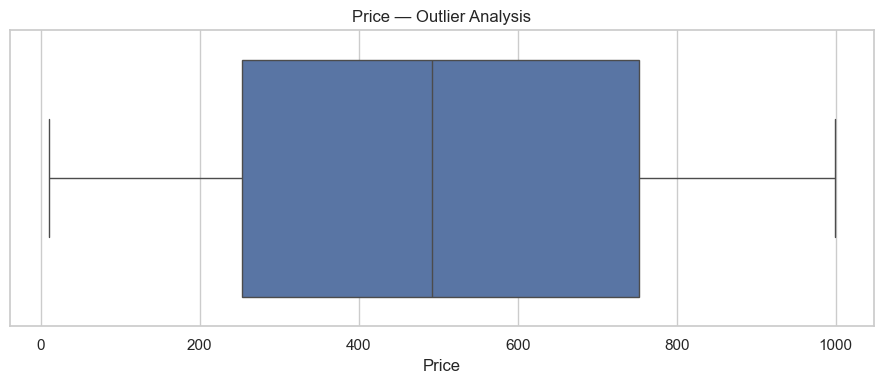

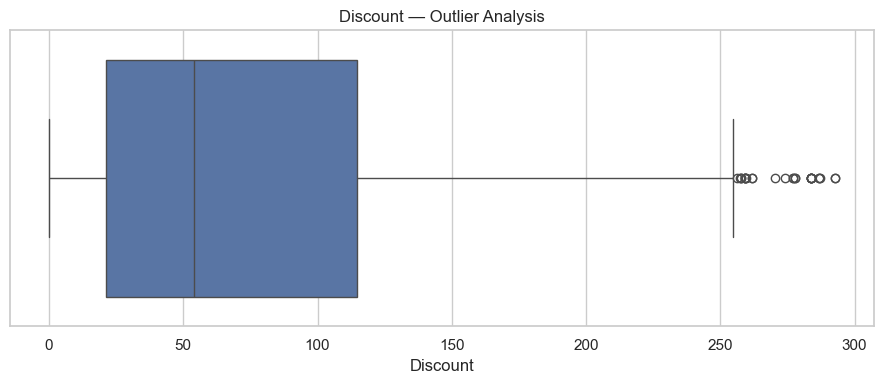

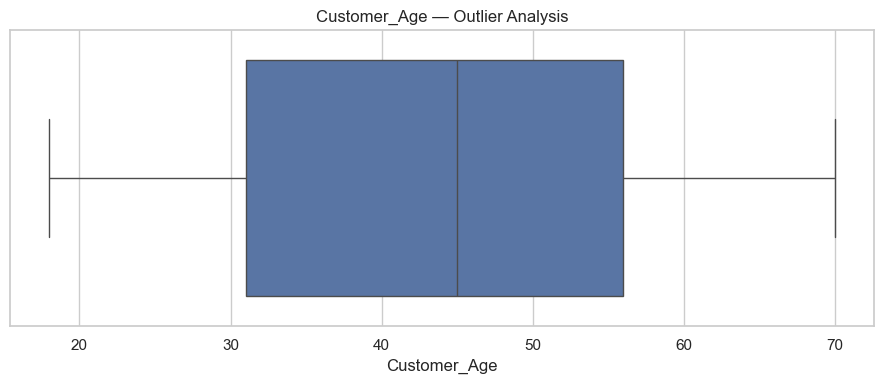

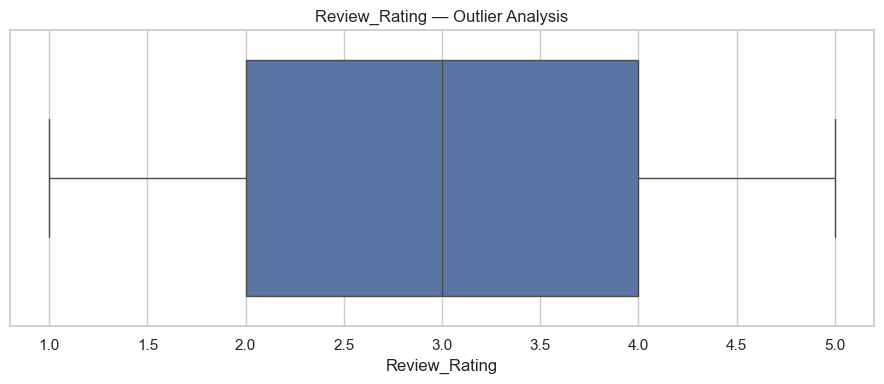

In [7]:

def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((series < lower) | (series > upper)).sum()), lower, upper

outlier_rows = []
for col in ["Price", "Discount", "Customer_Age", "Review_Rating"]:
    n, low, high = iqr_outliers(df[col])
    outlier_rows.append([col, n, round(n/len(df)*100,2), low, high])

display(pd.DataFrame(outlier_rows, columns=["Feature","Outlier Count","Outlier %","Lower Bound","Upper Bound"]))

for col in ["Price", "Discount", "Customer_Age", "Review_Rating"]:
    plt.figure(figsize=(9,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Outlier Analysis")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/outlier_{col}.png", dpi=200)
    plt.show()


## 6. Correlation Analysis

,Price,Discount,Customer_Age,Review_Rating,Purchase Probability
Price,1.000,0.656,-0.016,-0.013,-0.379
Discount,0.656,1.000,-0.031,-0.050,-0.169
Customer_Age,-0.016,-0.031,1.000,0.053,-0.181
Review_Rating,-0.013,-0.050,0.053,1.000,0.698
Purchase Probability,-0.379,-0.169,-0.181,0.698,1.000


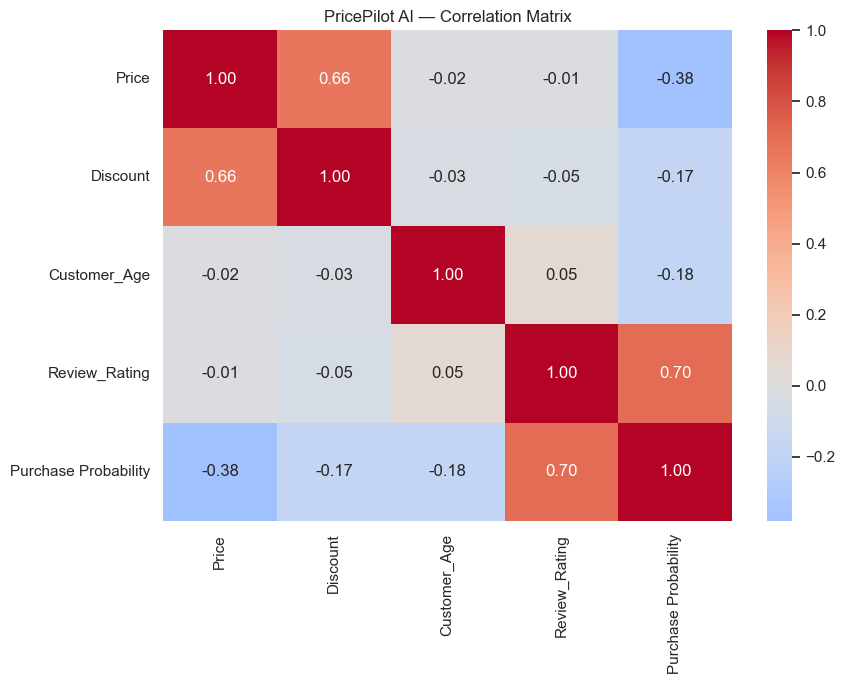

In [8]:

corr_cols = ["Price", "Discount", "Customer_Age", "Review_Rating", "Purchase Probability"]
corr = df[corr_cols].corr()

display(corr.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PricePilot AI — Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_matrix.png", dpi=200)
plt.show()


## 7. Price vs Purchase Probability

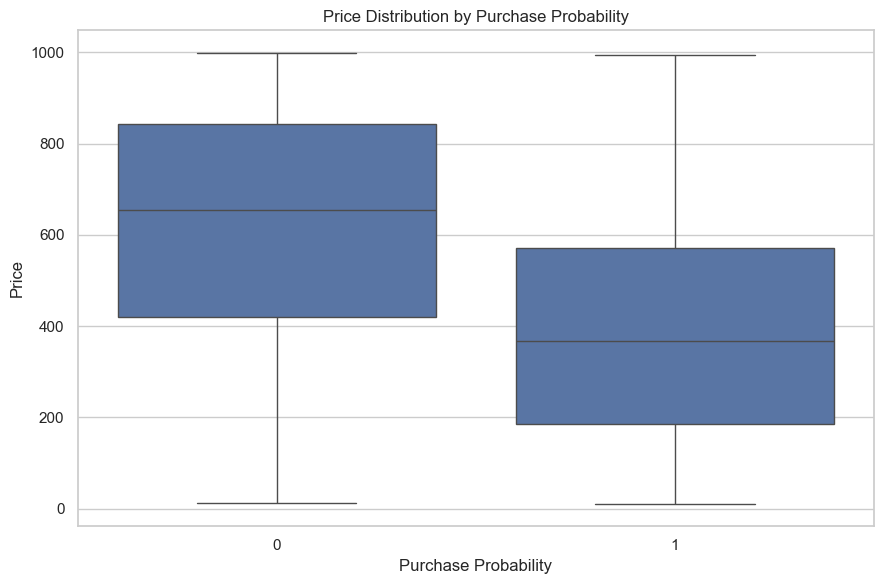

,count,mean,median,min,max
Purchase Probability,,,,,
0,1022,610.84,654.36,11.20,998.64
1,1022,394.72,367.83,10.86,994.62


In [9]:

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Purchase Probability", y="Price")
plt.title("Price Distribution by Purchase Probability")
plt.xlabel("Purchase Probability")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_vs_purchase_probability.png", dpi=200)
plt.show()

display(df.groupby("Purchase Probability")["Price"].agg(["count","mean","median","min","max"]).round(2))


## 8. Discount vs Purchase Probability

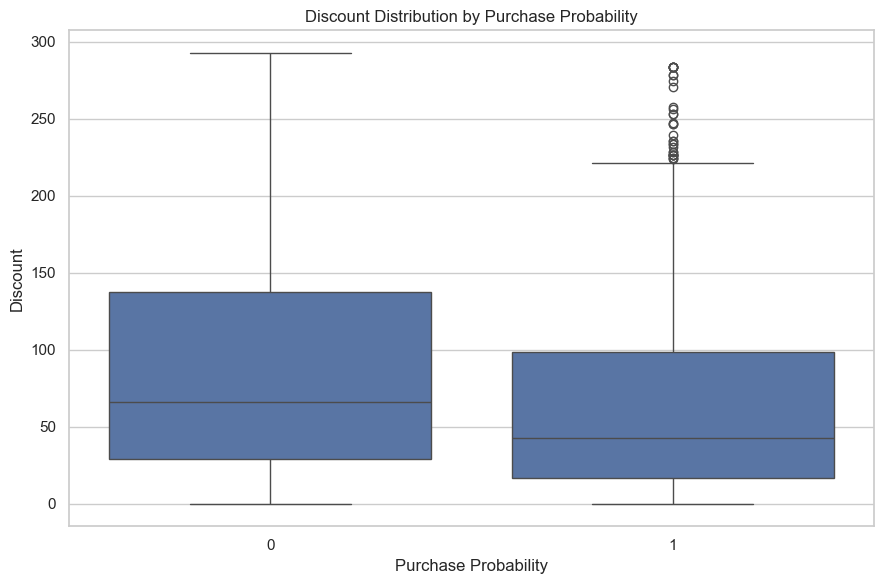

,mean,median,min,max
Purchase Probability,,,,
0,88.30,66.32,0.09,292.63
1,65.11,42.60,0.14,283.78


In [10]:

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Purchase Probability", y="Discount")
plt.title("Discount Distribution by Purchase Probability")
plt.xlabel("Purchase Probability")
plt.ylabel("Discount")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/discount_vs_purchase_probability.png", dpi=200)
plt.show()

display(df.groupby("Purchase Probability")["Discount"].agg(["mean","median","min","max"]).round(2))


## 9. Review Rating vs Purchase Probability

,Purchase Rate %
Review_Rating,
1,4.08
2,16.54
3,45.76
4,82.38
5,93.69


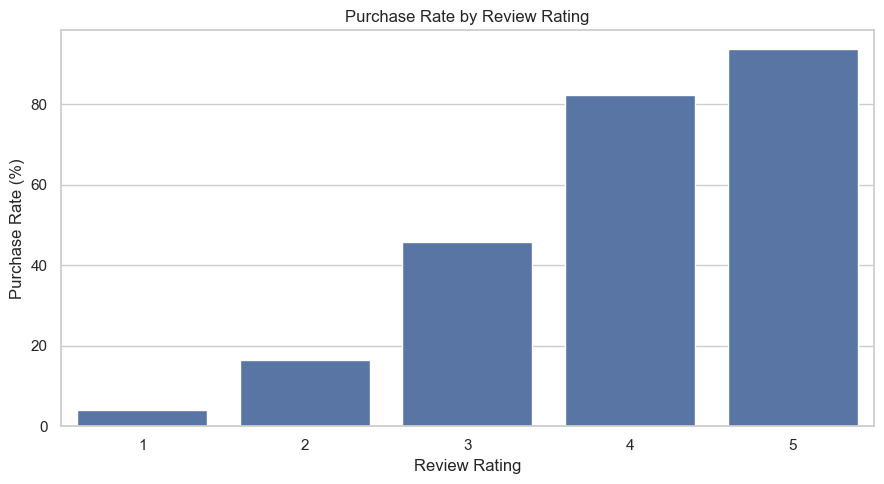

In [11]:

rating_purchase = df.groupby("Review_Rating")["Purchase Probability"].mean().mul(100).round(2)
display(rating_purchase.to_frame("Purchase Rate %"))

plt.figure(figsize=(9, 5))
sns.barplot(x=rating_purchase.index, y=rating_purchase.values)
plt.title("Purchase Rate by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Purchase Rate (%)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rating_vs_purchase_rate.png", dpi=200)
plt.show()


## 10. Category-wise Pricing & Purchase Rate

,Transactions,Average_Price,Average_Discount,Average_Rating,Purchase_Rate
Product_Category,,,,,
Books,513,489.02,78.30,3.12,53.22
Home & Kitchen,498,507.46,77.79,3.05,50.60
Electronics,512,503.61,78.78,3.09,50.20
Clothing,521,511.05,72.07,2.98,46.07


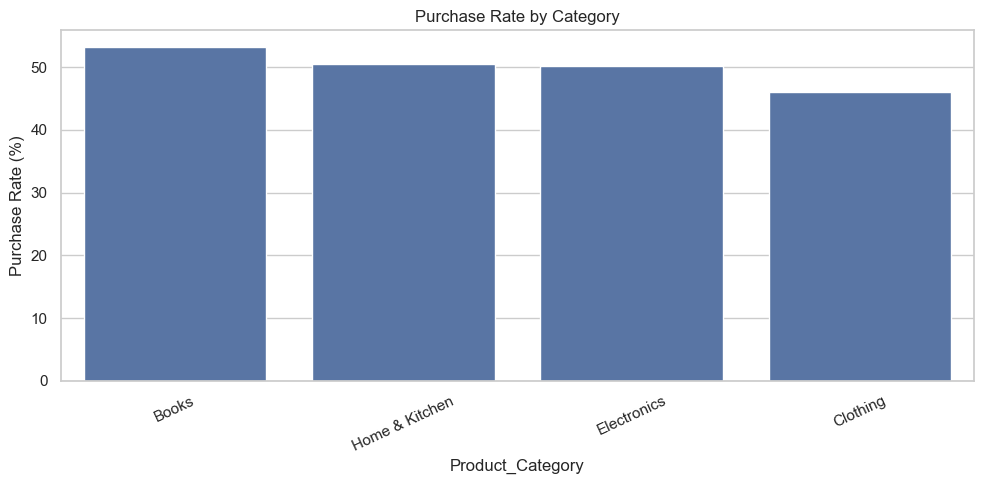

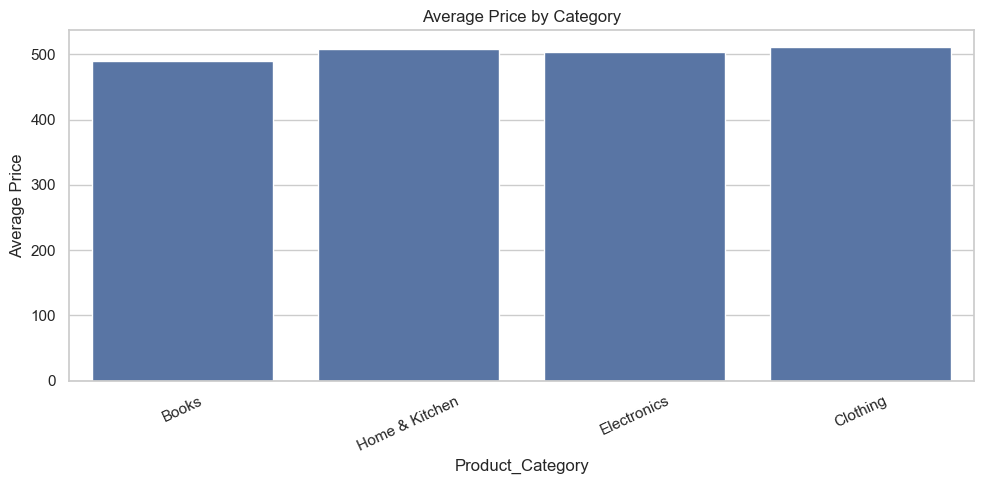

In [12]:

category_summary = df.groupby("Product_Category").agg(
    Transactions=("Transaction_ID","count"),
    Average_Price=("Price","mean"),
    Average_Discount=("Discount","mean"),
    Average_Rating=("Review_Rating","mean"),
    Purchase_Rate=("Purchase Probability","mean")
).sort_values("Purchase_Rate", ascending=False)

category_summary["Purchase_Rate"] = (category_summary["Purchase_Rate"]*100).round(2)
display(category_summary.round(2))

plt.figure(figsize=(10,5))
sns.barplot(data=category_summary.reset_index(), x="Product_Category", y="Purchase_Rate")
plt.title("Purchase Rate by Category")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/category_purchase_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=category_summary.reset_index(), x="Product_Category", y="Average_Price")
plt.title("Average Price by Category")
plt.ylabel("Average Price")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/category_average_price.png", dpi=200)
plt.show()


## 11. Customer Demographic Analysis

,Transactions,Average_Age,Average_Price,Average_Rating,Purchase_Rate
Customer_Gender,,,,,
Female,678,44.51,508.26,3.00,48.82
Male,736,44.25,498.11,3.06,50.00
Other,630,43.55,502.34,3.13,51.27


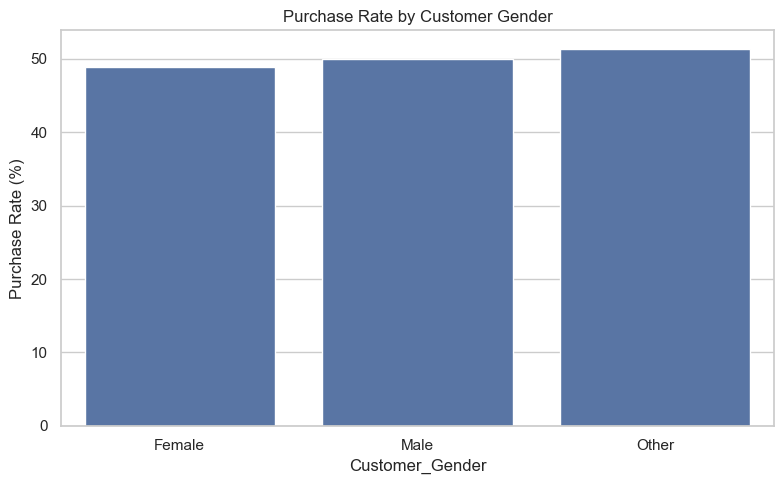

In [13]:

gender_summary = df.groupby("Customer_Gender").agg(
    Transactions=("Transaction_ID","count"),
    Average_Age=("Customer_Age","mean"),
    Average_Price=("Price","mean"),
    Average_Rating=("Review_Rating","mean"),
    Purchase_Rate=("Purchase Probability","mean")
)
gender_summary["Purchase_Rate"] *= 100
display(gender_summary.round(2))

plt.figure(figsize=(8,5))
sns.barplot(data=gender_summary.reset_index(), x="Customer_Gender", y="Purchase_Rate")
plt.title("Purchase Rate by Customer Gender")
plt.ylabel("Purchase Rate (%)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gender_purchase_rate.png", dpi=200)
plt.show()


## 12. Payment & Shipping Analysis

,count,Purchase Rate %
Payment_Method,,
Credit Card,559,50.45
Debit Card,526,53.99
Net Banking,481,49.06
PayPal,478,46.03


,count,Purchase Rate %
Shipping_Type,,
Express,1015,48.08
Standard,1029,51.90


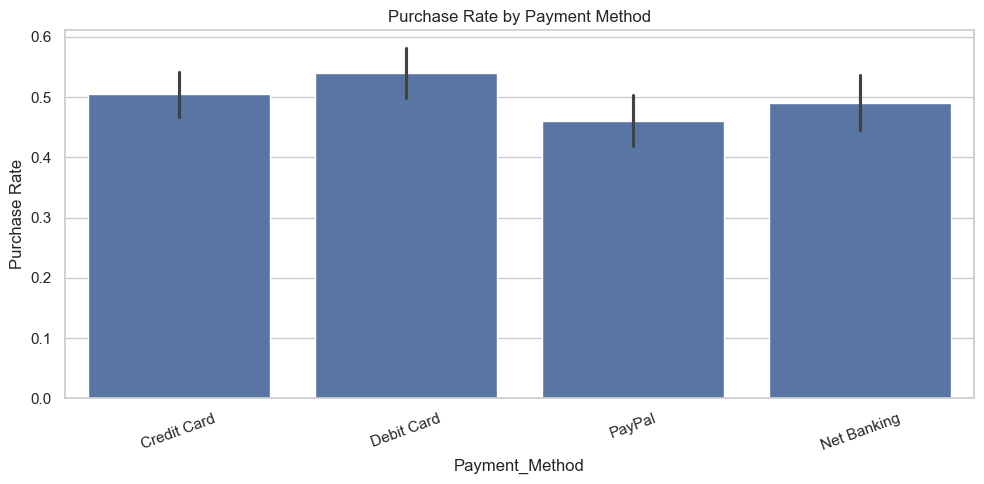

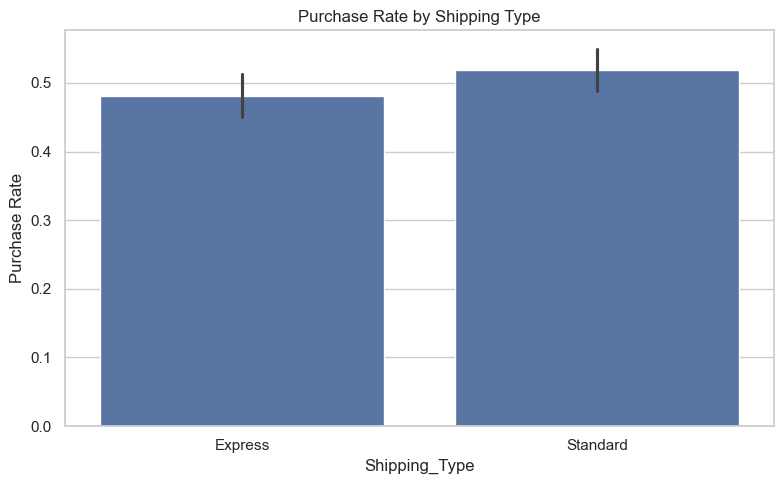

In [14]:

payment_summary = df.groupby("Payment_Method")["Purchase Probability"].agg(["count","mean"])
payment_summary["mean"] *= 100
payment_summary = payment_summary.rename(columns={"mean":"Purchase Rate %"})
display(payment_summary.round(2))

shipping_summary = df.groupby("Shipping_Type")["Purchase Probability"].agg(["count","mean"])
shipping_summary["mean"] *= 100
shipping_summary = shipping_summary.rename(columns={"mean":"Purchase Rate %"})
display(shipping_summary.round(2))

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Payment_Method", y="Purchase Probability", estimator="mean")
plt.title("Purchase Rate by Payment Method")
plt.ylabel("Purchase Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/payment_purchase_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Shipping_Type", y="Purchase Probability", estimator="mean")
plt.title("Purchase Rate by Shipping Type")
plt.ylabel("Purchase Rate")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shipping_purchase_rate.png", dpi=200)
plt.show()


## 13. Time-based Analysis

,Transactions,Purchase_Rate,Average_Price
Month,,,
1,201,51.24,538.07
2,157,43.95,554.79
3,152,53.29,400.19
4,190,43.68,467.50
5,166,54.82,510.31
6,187,52.41,482.38
7,164,54.88,538.72
8,170,55.29,537.92
9,150,43.33,490.82


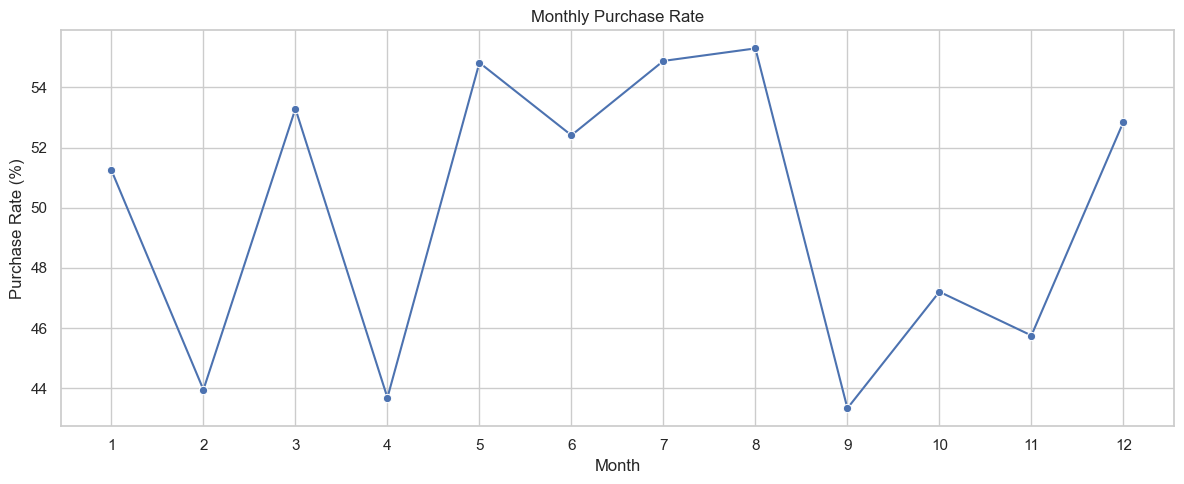

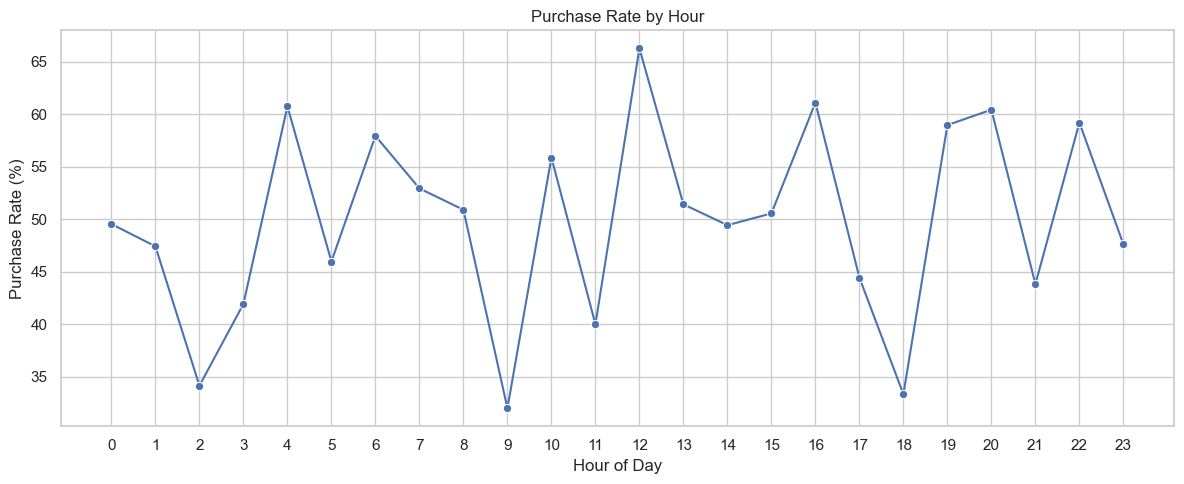

In [15]:

df["Purchase_Timestamp"] = pd.to_datetime(df["Purchase_Timestamp"], errors="coerce")
df["Month"] = df["Purchase_Timestamp"].dt.month
df["Month_Name"] = df["Purchase_Timestamp"].dt.month_name()
df["Day_of_Week"] = df["Purchase_Timestamp"].dt.day_name()
df["Hour"] = df["Purchase_Timestamp"].dt.hour

monthly = df.groupby("Month").agg(
    Transactions=("Transaction_ID","count"),
    Purchase_Rate=("Purchase Probability","mean"),
    Average_Price=("Price","mean")
)
monthly["Purchase_Rate"] *= 100
display(monthly.round(2))

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly.index, y=monthly["Purchase_Rate"], marker="o")
plt.title("Monthly Purchase Rate")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/monthly_purchase_rate.png", dpi=200)
plt.show()

hourly = df.groupby("Hour")["Purchase Probability"].mean().mul(100)
plt.figure(figsize=(12,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o")
plt.title("Purchase Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Purchase Rate (%)")
plt.xticks(range(0,24))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hourly_purchase_rate.png", dpi=200)
plt.show()


## 14. Key EDA Findings

In [16]:

overall_purchase_rate = df["Purchase Probability"].mean()*100
price_corr = df["Price"].corr(df["Purchase Probability"])
discount_corr = df["Discount"].corr(df["Purchase Probability"])
rating_corr = df["Review_Rating"].corr(df["Purchase Probability"])

best_category = df.groupby("Product_Category")["Purchase Probability"].mean().idxmax()
best_category_rate = df.groupby("Product_Category")["Purchase Probability"].mean().max()*100

findings = pd.DataFrame({
    "Metric": [
        "Dataset rows",
        "Dataset columns",
        "Missing values",
        "Exact duplicate rows",
        "Overall purchase rate",
        "Price vs purchase probability correlation",
        "Discount vs purchase probability correlation",
        "Review rating vs purchase probability correlation",
        "Highest purchase-rate category"
    ],
    "Value": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        round(overall_purchase_rate,2),
        round(price_corr,3),
        round(discount_corr,3),
        round(rating_corr,3),
        f"{best_category} ({best_category_rate:.2f}%)"
    ]
})
display(findings)

print("\nBusiness interpretation:")
print(f"• Purchase probability is evenly balanced at about {overall_purchase_rate:.2f}%.")
print(f"• Price has a negative correlation with purchase probability ({price_corr:.3f}), suggesting higher prices are associated with lower purchase likelihood in this dataset.")
print(f"• Discount also has a negative correlation with purchase probability ({discount_corr:.3f}); this is an association, not proof that discounts reduce purchases.")
print(f"• Review rating has the strongest positive relationship with purchase probability ({rating_corr:.3f}).")
print(f"• {best_category} has the highest category-level purchase rate ({best_category_rate:.2f}%).")
print("• The dataset contains a large number of exact duplicate rows, so duplicate handling should be explicitly decided before model training.")


,Metric,Value
0,Dataset rows,2044
1,Dataset columns,17
2,Missing values,0
3,Exact duplicate rows,799
4,Overall purchase rate,50.0
5,Price vs purchase probability correlation,-0.379
6,Discount vs purchase probability correlation,-0.169
7,Review rating vs purchase probability correlation,0.698
8,Highest purchase-rate category,Books (53.22%)



Business interpretation:
• Purchase probability is evenly balanced at about 50.00%.
• Price has a negative correlation with purchase probability (-0.379), suggesting higher prices are associated with lower purchase likelihood in this dataset.
• Discount also has a negative correlation with purchase probability (-0.169); this is an association, not proof that discounts reduce purchases.
• Review rating has the strongest positive relationship with purchase probability (0.698).
• Books has the highest category-level purchase rate (53.22%).
• The dataset contains a large number of exact duplicate rows, so duplicate handling should be explicitly decided before model training.


## 15. Modeling Preparation Notes

In [17]:

## Modeling preparation

Based on this EDA, the next stage can investigate:

1. **Purchase probability prediction** — classification target: `Purchase Probability`.
2. **Dynamic pricing / price recommendation** — study how price, discount, customer characteristics and product category relate to purchase likelihood.
3. **Feature engineering** — extract month, day-of-week and hour from `Purchase_Timestamp`.
4. **Data quality** — investigate the 799 exact duplicate rows before training.
5. **Categorical encoding** — Product_Category, Customer_Gender, Payment_Method and Shipping_Type require encoding for most ML models.
6. **Model evaluation** — use classification metrics such as accuracy, precision, recall, F1-score and ROC-AUC for purchase-probability models.

Note: this dataset does **not** contain explicit sales volume, revenue, inventory or competitor-price columns, so those analyses cannot be claimed from this dataset alone.


SyntaxError: invalid character '—' (U+2014) (1571362274.py, line 5)